In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [76]:
df = pd.read_csv('student_performance.csv',sep=";")
#https://www.kaggle.com/datasets/devansodariya/student-performance-data

In [77]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [78]:
len(df.columns)

33

In [79]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

In [80]:
for x in df.columns:
    print("--------------")
    print("**")
    print("Column Name : ",x)
    print("**")

    print(df[x].unique())

--------------
**
Column Name :  school
**
<ArrowStringArray>
['GP', 'MS']
Length: 2, dtype: str
--------------
**
Column Name :  sex
**
<ArrowStringArray>
['F', 'M']
Length: 2, dtype: str
--------------
**
Column Name :  age
**
[18 17 15 16 19 22 20 21]
--------------
**
Column Name :  address
**
<ArrowStringArray>
['U', 'R']
Length: 2, dtype: str
--------------
**
Column Name :  famsize
**
<ArrowStringArray>
['GT3', 'LE3']
Length: 2, dtype: str
--------------
**
Column Name :  Pstatus
**
<ArrowStringArray>
['A', 'T']
Length: 2, dtype: str
--------------
**
Column Name :  Medu
**
[4 1 3 2 0]
--------------
**
Column Name :  Fedu
**
[4 1 2 3 0]
--------------
**
Column Name :  Mjob
**
<ArrowStringArray>
['at_home', 'health', 'other', 'services', 'teacher']
Length: 5, dtype: str
--------------
**
Column Name :  Fjob
**
<ArrowStringArray>
['teacher', 'other', 'services', 'health', 'at_home']
Length: 5, dtype: str
--------------
**
Column Name :  reason
**
<ArrowStringArray>
['course', 'o

In [81]:
df = pd.get_dummies(df, columns=['school','Mjob','Fjob','reason','guardian'])

In [82]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

cols = ['sex','address','famsize','Pstatus','schoolsup',
               'famsup','paid','activities','nursery','higher','internet','romantic']

for col in cols:
    df[col] = le.fit_transform(df[col])

In [83]:
df.head(10)

,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,failures,...,Fjob_other,Fjob_services,Fjob_teacher,reason_course,reason_home,reason_other,reason_reputation,guardian_father,guardian_mother,guardian_other
0,0,18,1,0,0,4,4,2,2,0,...,False,False,True,True,False,False,False,False,True,False
1,0,17,1,0,1,1,1,1,2,0,...,True,False,False,True,False,False,False,True,False,False
2,0,15,1,1,1,1,1,1,2,3,...,True,False,False,False,False,True,False,False,True,False
3,0,15,1,0,1,4,2,1,3,0,...,False,True,False,False,True,False,False,False,True,False
4,0,16,1,0,1,3,3,1,2,0,...,True,False,False,False,True,False,False,True,False,False
5,1,16,1,1,1,4,3,1,2,0,...,True,False,False,False,False,False,True,False,True,False
6,1,16,1,1,1,2,2,1,2,0,...,True,False,False,False,True,False,False,False,True,False
7,0,17,1,0,0,4,4,2,2,0,...,False,False,True,False,True,False,False,False,True,False
8,1,15,1,1,0,3,2,1,2,0,...,True,False,False,False,True,False,False,False,True,False
9,1,15,1,0,1,3,4,1,2,0,...,True,False,False,False,True,False,False,False,True,False


In [84]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 47 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   sex                395 non-null    int64
 1   age                395 non-null    int64
 2   address            395 non-null    int64
 3   famsize            395 non-null    int64
 4   Pstatus            395 non-null    int64
 5   Medu               395 non-null    int64
 6   Fedu               395 non-null    int64
 7   traveltime         395 non-null    int64
 8   studytime          395 non-null    int64
 9   failures           395 non-null    int64
 10  schoolsup          395 non-null    int64
 11  famsup             395 non-null    int64
 12  paid               395 non-null    int64
 13  activities         395 non-null    int64
 14  nursery            395 non-null    int64
 15  higher             395 non-null    int64
 16  internet           395 non-null    int64
 17  romantic           395 non-

In [85]:
df.isnull().sum()

sex                  0
age                  0
address              0
famsize              0
Pstatus              0
Medu                 0
Fedu                 0
traveltime           0
studytime            0
failures             0
schoolsup            0
famsup               0
paid                 0
activities           0
nursery              0
higher               0
internet             0
romantic             0
famrel               0
freetime             0
goout                0
Dalc                 0
Walc                 0
health               0
absences             0
G1                   0
G2                   0
G3                   0
school_GP            0
school_MS            0
Mjob_at_home         0
Mjob_health          0
Mjob_other           0
Mjob_services        0
Mjob_teacher         0
Fjob_at_home         0
Fjob_health          0
Fjob_other           0
Fjob_services        0
Fjob_teacher         0
reason_course        0
reason_home          0
reason_other         0
reason_repu

In [86]:
df.describe()

,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,failures,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,...,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,0.473418,16.696203,0.777215,0.288608,0.896203,2.749367,2.521519,1.448101,2.035443,0.334177,...,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,0.499926,1.276043,0.416643,0.453690,0.305384,1.094735,1.088201,0.697505,0.839240,0.743651,...,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,0.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,0.000000,16.000000,1.000000,0.000000,1.000000,2.000000,2.000000,1.000000,1.000000,0.000000,...,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,0.000000,17.000000,1.000000,0.000000,1.000000,3.000000,2.000000,1.000000,2.000000,0.000000,...,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,1.000000,18.000000,1.000000,1.000000,1.000000,4.000000,3.000000,2.000000,2.000000,0.000000,...,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,1.000000,22.000000,1.000000,1.000000,1.000000,4.000000,4.000000,4.000000,4.000000,3.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [87]:
df.shape

(395, 47)

In [88]:
df.columns

Index(['sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid',
       'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel',
       'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2',
       'G3', 'school_GP', 'school_MS', 'Mjob_at_home', 'Mjob_health',
       'Mjob_other', 'Mjob_services', 'Mjob_teacher', 'Fjob_at_home',
       'Fjob_health', 'Fjob_other', 'Fjob_services', 'Fjob_teacher',
       'reason_course', 'reason_home', 'reason_other', 'reason_reputation',
       'guardian_father', 'guardian_mother', 'guardian_other'],
      dtype='str')

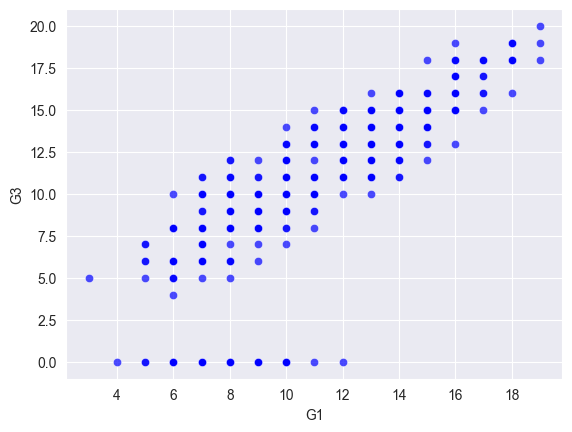

In [89]:
sns.scatterplot(x='G1', y='G3', data=df, color='blue', alpha=0.7)
plt.show()

<Axes: xlabel='age', ylabel='G3'>

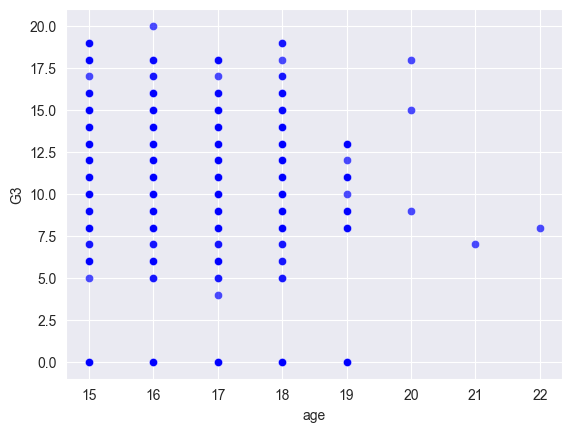

In [90]:
sns.scatterplot(x='age', y='G3', data=df, color='blue', alpha=0.7)

<Axes: xlabel='studytime', ylabel='G3'>

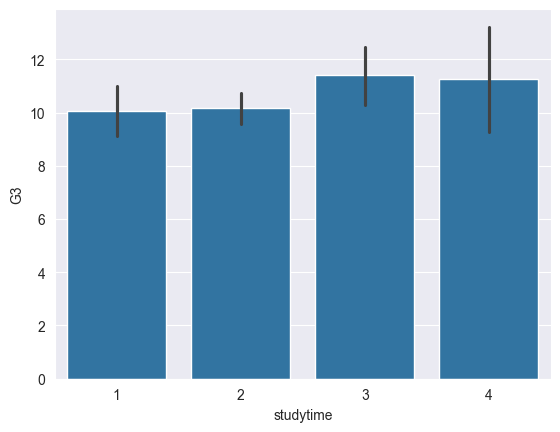

In [91]:
sns.barplot(x='studytime', y='G3', data=df)

In [92]:
df_num = df.select_dtypes(include=['int', 'float'])

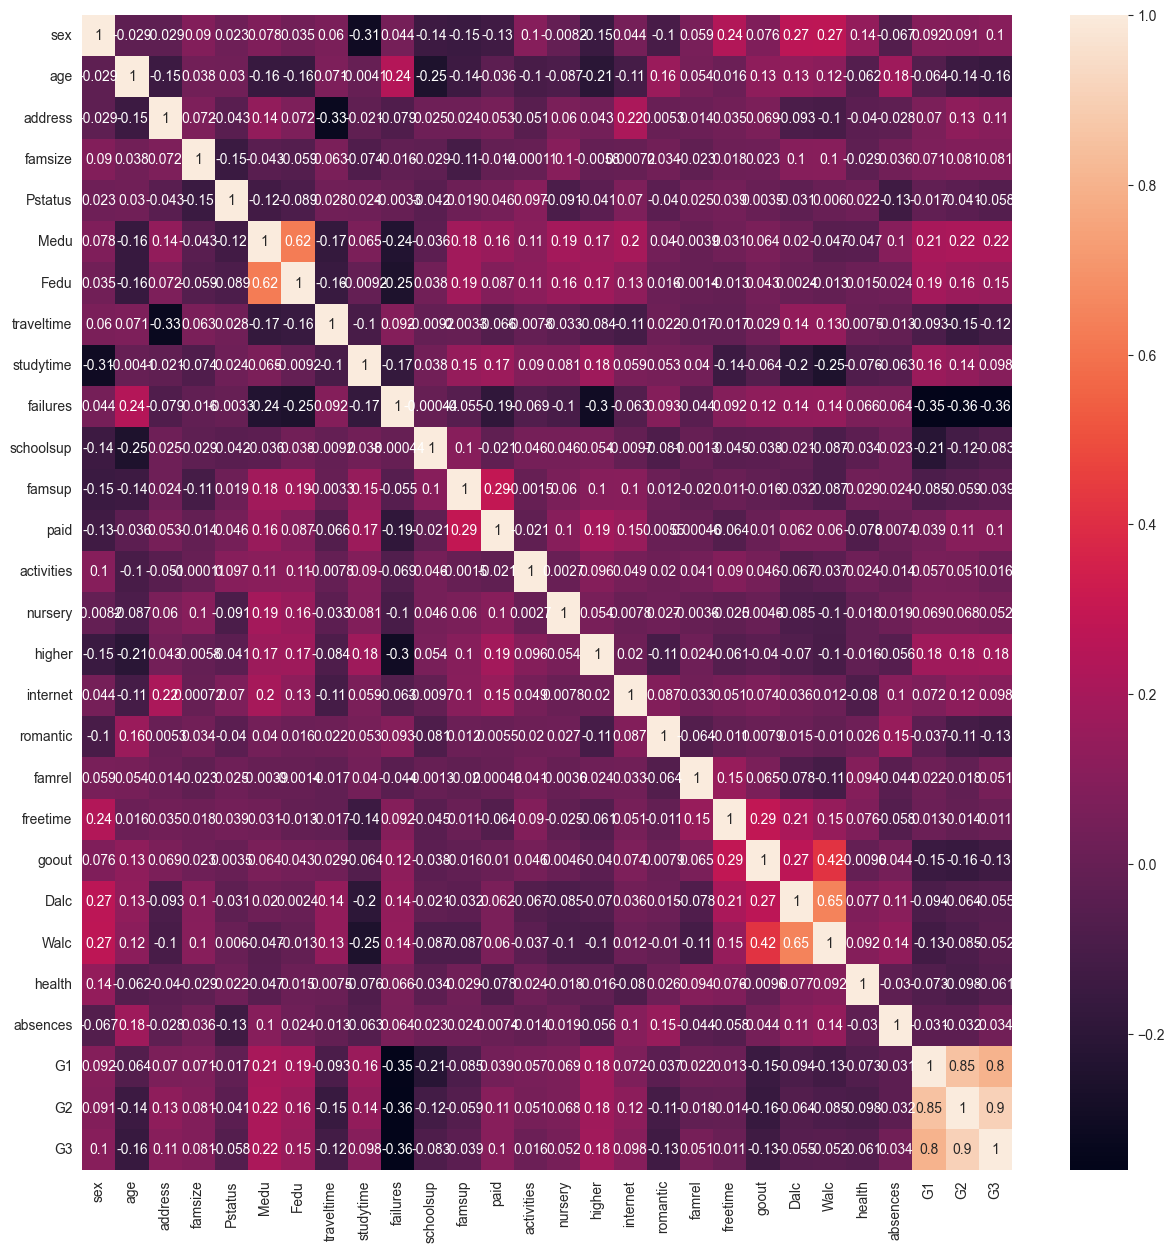

In [93]:
plt.figure(figsize = (15,15))
sns.heatmap(df_num.corr(), annot=True)
plt.show()

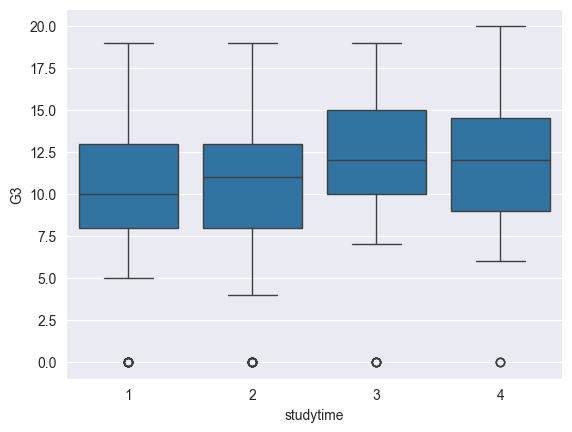

In [94]:
sns.boxplot(x="studytime", y="G3", data=df)
plt.show()

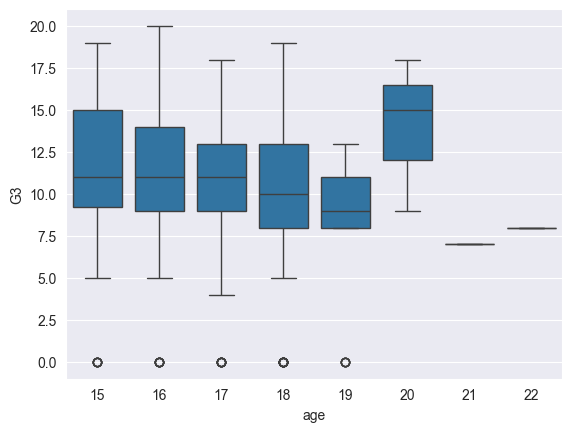

In [95]:
sns.boxplot(x="age", y="G3", data=df)
plt.show()

In [96]:
from sklearn.svm import SVR

In [97]:
svr = SVR()

In [98]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [99]:
X = df.drop('G3',axis=1)
y = df['G3']

In [100]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [101]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

In [102]:
param_grid = {
    'kernel' : ['rbf', 'linear', 'poly'],
    'C'      : [0.1, 1, 10, 100],
    'epsilon': [0.01, 0.1, 0.5, 1.0],
    'gamma'  : ['scale', 'auto']
}

In [103]:
grid= GridSearchCV(estimator =svr,param_grid=param_grid,cv= 5, scoring='r2', n_jobs=-1)
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVR()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'epsilon': [0.01, 0.1, ...], 'gamma': ['scale', 'auto'], 'kernel': ['rbf', 'linear', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the sc

In [104]:
grid.best_params_

{'C': 1, 'epsilon': 1.0, 'gamma': 'scale', 'kernel': 'linear'}

In [105]:
grid.best_score_

np.float64(0.8189939768554746)

In [106]:
best_svr = grid.best_estimator_
y_pred   = best_svr.predict(X_test)

mse  = mean_squared_error(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print("Mean Absolute Error: ", mae)
print("Mean Squared Error: ", mse)
print("R2 Score: ", r2)

Mean Absolute Error:  1.3293412716023751
Mean Squared Error:  4.914830060651085
R2 Score:  0.760311205509616


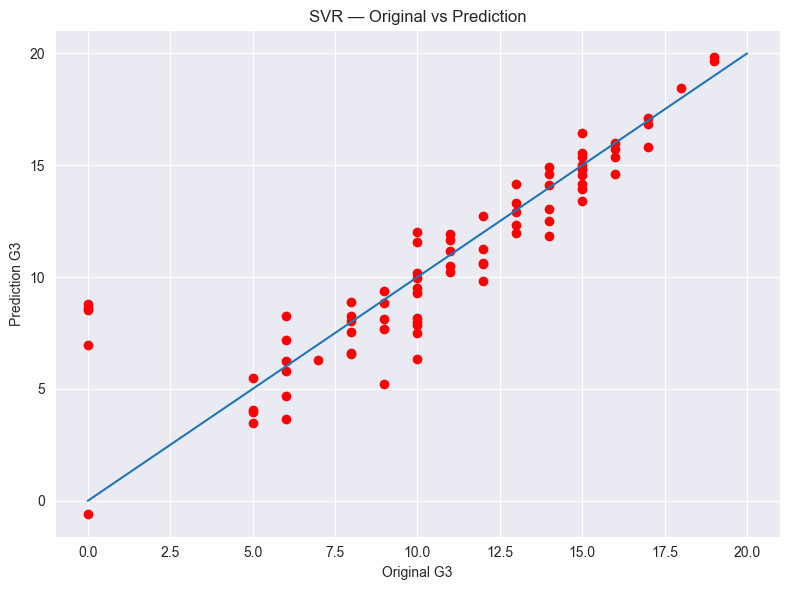

In [107]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='red')
plt.plot([y.min(), y.max()], [y.min(), y.max()])
plt.xlabel('Original G3')
plt.ylabel('Prediction G3')
plt.title('SVR — Original vs Prediction')
plt.tight_layout()
plt.show()

In [108]:
grid.cv_results_

{'mean_fit_time': array([4.22964096e-03, 1.00391865e-02, 4.00829315e-03, 4.86550331e-03,
        1.00656986e-02, 4.55660820e-03, 5.03106117e-03, 1.01626396e-02,
        3.00965309e-03, 4.29077148e-03, 9.41882133e-03, 3.31411362e-03,
        5.03897667e-03, 7.72013664e-03, 4.84776497e-03, 4.08444405e-03,
        7.26537704e-03, 4.00466919e-03, 3.66554260e-03, 4.01654243e-03,
        2.94265747e-03, 2.84090042e-03, 6.89878464e-03, 3.08065414e-03,
        5.34105301e-03, 9.06177998e-02, 7.56554604e-03, 5.32283783e-03,
        1.12153053e-01, 5.34605980e-03, 7.39283562e-03, 7.95380116e-02,
        4.26292419e-03, 4.42194939e-03, 6.57594681e-02, 5.31272888e-03,
        5.60898781e-03, 7.68127918e-02, 3.96127701e-03, 4.59318161e-03,
        8.00983429e-02, 6.73522949e-03, 4.48126793e-03, 6.43537045e-02,
        3.61361504e-03, 3.22031975e-03, 4.32965279e-02, 3.30152512e-03,
        1.23850346e-02, 1.26332207e+00, 6.99405670e-03, 1.50314808e-02,
        1.04930677e+00, 6.35652542e-03, 1.16583

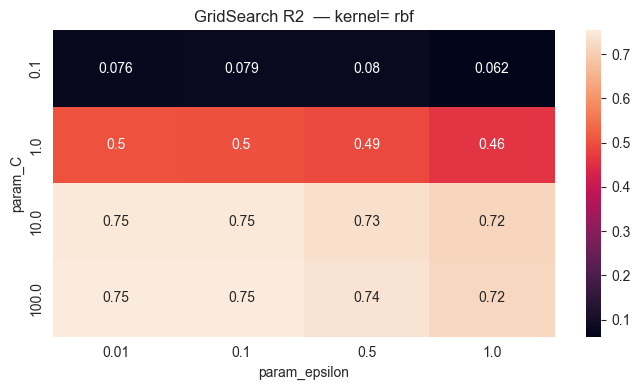

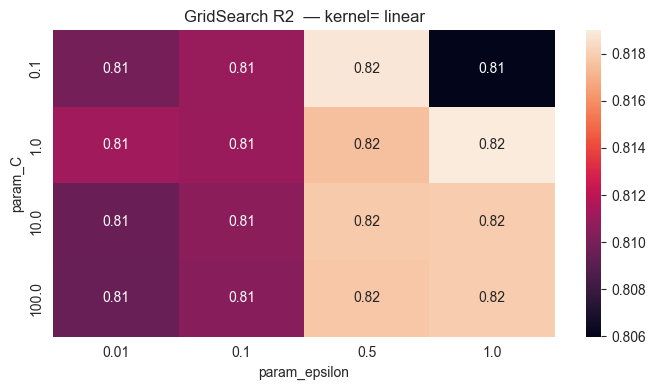

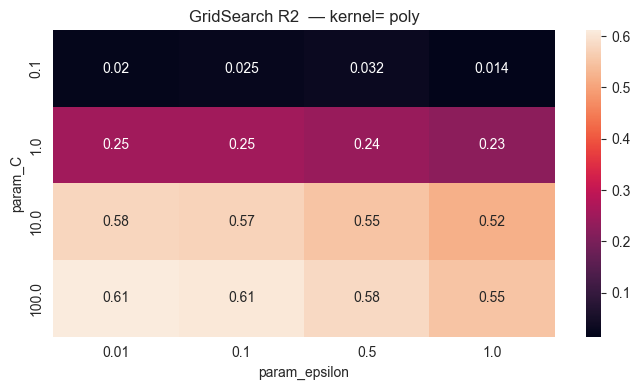

In [109]:
cv_results = pd.DataFrame(grid.cv_results_)

for kernel in param_grid['kernel']:
    x = cv_results[cv_results['param_kernel'] == kernel]
    pivot  = x.pivot_table(
        index='param_C',
        columns='param_epsilon',
        values='mean_test_score'
    )

    plt.figure(figsize=(7, 4))
    sns.heatmap(pivot, annot=True)
    plt.title(f'GridSearch R2  — kernel= {kernel}')
    plt.tight_layout()
    plt.show()